# Bloco 2 - VARIATIONAL QUANTUM EIGENSOLVER - VQE para TSP

| BIO - Quantum (grupo 13)


Este notebook implementa um **Variational Quantum Eigensolver (VQE)** para minimizar um **Hamiltoniano QUBO/Ising do TSP**, construído a partir da codificação em matriz binária mostrada nos seus slides.

Vamos:
1. Definir uma instância pequena de TSP (matriz de distâncias).
2. Construir o objetivo **QUBO**: distância + restrições via penalidade.
3. Mapear o QUBO com $x\in\{0,1\}$ para um **Hamiltoniano Ising/Pauli-Z** usando $x = (1 - Z)/2$.
4. Rodar VQE com PennyLane + PyTorch.
5. Decodificar o melhor bitstring em uma rota e comparar com o ótimo por força bruta.

### Libs & Setup

In [1]:
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pennylane as qml
import torch
from scipy.spatial import distance_matrix

print("PennyLane:", qml.__version__)
print("Torch:", torch.__version__)


PennyLane: 0.44.0
Torch: 2.10.0+cu128


In [2]:
# check for GPU availability
if torch.cuda.is_available():
    print("GPU is available. Using GPU.")

GPU is available. Using GPU.


#### Setar seed para reprodutibilidade

In [3]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Stronger determinism (mostly relevant on GPU / some ops)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

## 1) Definição do problema (TSP brinquedo)

Usamos $n$ cidades e uma matriz de distâncias $d_{ij}$. Mantenha $n\le 5$ para validar rapidamente com força bruta.

Você pode trocar a matriz de distâncias depois.


n = 5
Distance matrix D:
 [[ 0.   50.17 82.42 32.76 33.2 ]
 [50.17  0.   72.64 72.51 17.06]
 [82.42 72.64  0.   71.69 70.92]
 [32.76 72.51 71.69  0.   56.56]
 [33.2  17.06 70.92 56.56  0.  ]]


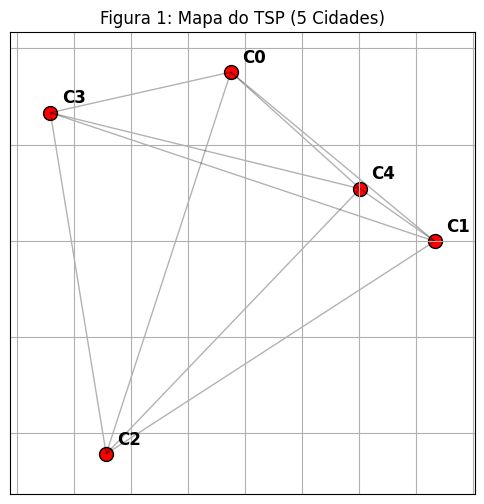

In [4]:
# ---- Generate random TSP instance ----
NUM_CIDADES = 5  # keep small for VQE (n^2 qubits total)
cities = np.random.rand(NUM_CIDADES, 2) * 100
D = distance_matrix(cities, cities)

n = D.shape[0]
assert D.shape == (n, n)
print("n =", n)
print("Distance matrix D:\n", np.round(D, 2))

# ---- Visualize cities and connections ----
plt.figure(figsize=(6, 6))
plt.scatter(cities[:, 0], cities[:, 1], c="red", edgecolors="black", s=100)
for i, (x, y) in enumerate(cities):
    plt.text(x + 2, y + 2, f"C{i}", fontsize=12, fontweight="bold")

# Draw full connection graph
G = nx.complete_graph(NUM_CIDADES)
pos = {i: cities[i] for i in range(NUM_CIDADES)}
nx.draw_networkx_edges(G, pos, alpha=0.3)

plt.title(f"Figura 1: Mapa do TSP ({NUM_CIDADES} Cidades)")
plt.grid(True)
plt.show()


## 2) Codificação: matriz binária $x_{i,t}$

- $x_{i,t}=1$ significa que a cidade **i** é visitada no passo/posição **t**.
- Total de qubits: $n^2$ (um por $x_{i,t}$).

Mapeamos $(i,t) \to q$ com `q = i*n + t`.


In [5]:
def qindex(i: int, t: int, n: int) -> int:
    """Mapeia (cidade i, tempo t) para o índice de qubit em [0, n^2-1]."""
    return i * n + t


# quick sanity:
for i in range(n):
    for t in range(n):
        assert 0 <= qindex(i, t, n) < n * n
print("Total qubits:", n * n)


Total qubits: 25


## 3) Construção do QUBO (custo + restrições)

### Objetivo (distância)

$$
H_{\text{dist}} = \sum_{t=0}^{n-1}\sum_{i,j} d_{ij}\, x_{i,t}\, x_{j,(t+1 \bmod n)}
$$

### Restrições (penalidade $A$)

1. **Cidade única** (cada cidade aparece exatamente uma vez):

$$
H_{\text{cidade}} = \sum_i \left(\sum_t x_{i,t} - 1\right)^2
$$

2. **Tempo único** (em cada tempo, exatamente uma cidade):

$$
H_{\text{tempo}} = \sum_t \left(\sum_i x_{i,t} - 1\right)^2
$$

### Hamiltoniano total

$$
H = H_{\text{dist}} + A\,H_{\text{cidade}} + A\,H_{\text{tempo}}
$$

Primeiro construímos os coeficientes do **QUBO** sobre variáveis binárias e, depois, mapeamos para operadores de Pauli-$Z$.


In [6]:
def add_qubo_term(Q, a, b, coeff):
    """Acumula o coeficiente do QUBO para x_a x_b (com a<=b)."""
    if a > b:
        a, b = b, a
    Q[(a, b)] = Q.get((a, b), 0.0) + float(coeff)


def build_tsp_qubo(D: np.ndarray, A: float):
    """Retorna um dicionário QUBO para o TSP usando a codificação x_{i,t}.

    O QUBO é representado como dict {(a,b): coef} com a<=b, onde o termo é coef * x_a * x_b.
    Termos lineares são armazenados com a==b.
    Também retorna o deslocamento constante gerado ao expandir as restrições (útil para reporte).
    """
    n = D.shape[0]
    Q = {}
    const = 0.0

    # --- Distance objective
    for t in range(n):
        tp1 = (t + 1) % n
        for i in range(n):
            a = qindex(i, t, n)
            for j in range(n):
                b = qindex(j, tp1, n)
                add_qubo_term(Q, a, b, D[i, j])

    # --- City-unique constraints
    for i in range(n):
        # constant +A*1
        const += A * 1.0
        # linear terms: -A * x_{i,t}
        for t in range(n):
            a = qindex(i, t, n)
            add_qubo_term(Q, a, a, -A)
        # quadratic terms: +2A * x_{i,t}x_{i,u}
        for t in range(n):
            for u in range(t + 1, n):
                a = qindex(i, t, n)
                b = qindex(i, u, n)
                add_qubo_term(Q, a, b, 2.0 * A)

    # --- Time-unique constraints
    for t in range(n):
        const += A * 1.0
        for i in range(n):
            a = qindex(i, t, n)
            add_qubo_term(Q, a, a, -A)
        for i in range(n):
            for j in range(i + 1, n):
                a = qindex(i, t, n)
                b = qindex(j, t, n)
                add_qubo_term(Q, a, b, 2.0 * A)

    return Q, const


d_max = np.max(D[~np.eye(n, dtype=bool)])  # max off-diagonal distance
A = float(n * d_max * 5)  # total cost range as upper bound
print(f"d_max = {d_max:.2f} | A = {A:.2f}")
Q, const_offset = build_tsp_qubo(D, A)
print("QUBO terms:", len(Q), " | constant offset:", const_offset)


d_max = 82.42 | A = 2060.54
QUBO terms: 225  | constant offset: 20605.387264337623


## 4) Mapear QUBO para um Hamiltoniano Pauli-Z

Mapeamento binário → Pauli-Z:
$
x = \frac{1 - Z}{2}
$

Então:
- Termo linear: $c\,x_a \to \tfrac{c}{2}I - \tfrac{c}{2}Z_a$
- Termo quadrático: $c\,x_a x_b \to \tfrac{c}{4}(I - Z_a - Z_b + Z_a Z_b)$

Acumulamos tudo em um `qml.Hamiltonian` do PennyLane.


In [7]:
def qubo_to_ising_hamiltonian(Q, n_qubits: int):
    """Converte o dicionário QUBO {(a,b):coef} em (qml.Hamiltonian, deslocamento_constante)."""
    coeffs = []
    ops = []
    const = 0.0

    def add_op(c, op):
        # skip near-zero terms to keep Hamiltonian compact
        if abs(c) > 1e-12:
            coeffs.append(float(c))
            ops.append(op)

    for (a, b), c in Q.items():
        if a == b:
            # c * x_a
            const += c / 2.0
            add_op(-c / 2.0, qml.PauliZ(a))
        else:
            # c * x_a x_b
            const += c / 4.0
            add_op(-c / 4.0, qml.PauliZ(a))
            add_op(-c / 4.0, qml.PauliZ(b))
            add_op(c / 4.0, qml.PauliZ(a) @ qml.PauliZ(b))

    H = qml.Hamiltonian(coeffs, ops)
    return H, const

n_qubits = n * n
H, const_ising = qubo_to_ising_hamiltonian(Q, n_qubits)
total_const = const_offset + const_ising
print("Ising Hamiltonian terms:", len(H.ops))
print("Total constant shift (QUBO expand + mapping):", total_const)


Ising Hamiltonian terms: 625
Total constant shift (QUBO expand + mapping): 73518.65159438459


## 5) Configuração do VQE (PennyLane + Torch)

Usamos um ansatz do tipo hardware-efficient (`StronglyEntanglingLayers`) e minimizamos a energia esperada $\langle H \rangle$.


In [8]:
n_layers = 2  # mais camadas => mais parametros e otimizacao mais dificil
n_restarts = 10
steps_per_restart = 300
best_E = float("inf")
best_weights = None
best_seed = None
best_energy_hist = None

In [9]:
# Device: tenta usar GPU (lightning.gpu) se estiver instalada; else, CPU (lightning.qubit)
device_name = "lightning.gpu"
try:
    dev = qml.device(
        device_name, wires=n_qubits, shots=None
    )  # shots=None => expectativa analitica
    print(f"Usando device: {device_name} (GPU)")
except Exception as e:
    device_name = "lightning.qubit"
    dev = qml.device(
        device_name, wires=n_qubits, shots=None
    )  # shots=None => expectativa analitica
    print(f"Usando device: {device_name} (CPU). Fallback: {type(e).__name__}: {e}")


@qml.qnode(dev, interface="torch", diff_method="adjoint")
def energy_qnode(weights):
    for w in range(n_qubits):
        qml.Hadamard(wires=w)
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.expval(H)


def vqe_train(weights, opt, steps=300, print_every=100, verbose=False):
    history = []
    for step in range(steps):
        opt.zero_grad(set_to_none=True)

        E = energy_qnode(weights)
        if not torch.isfinite(E.detach()):
            print(
                f"[WARN] step {step:4d} | energia não finita ({float(E.detach().cpu())}). Interrompendo este restart."
            )
            break

        E.backward()
        grad_norm = (
            float(weights.grad.detach().norm().cpu())
            if weights.grad is not None
            else 0.0
        )
        opt.step()

        e_val = float(E.detach().cpu())
        history.append(e_val)

        if verbose and (step % print_every == 0 or step == steps - 1):
            print(f"step {step:4d} | E = {e_val: .6f} | grad_norm = {grad_norm: .3e}")
    return history


Usando device: lightning.gpu (GPU)


In [10]:
print(
    f"Iniciando VQE | restarts={n_restarts} | steps/restart={steps_per_restart} | "
    f"layers={n_layers} | qubits={n_qubits} | device={device_name}"
)

failed_restarts = 0

for seed in range(n_restarts):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    weights = torch.nn.Parameter(
        0.1 * torch.randn(n_layers, n_qubits, 3, dtype=torch.float64)
    )
    opt = torch.optim.Adam([weights], lr=0.02)

    print(f"\n[restart {seed:2d}] seed={seed}")
    try:
        history = vqe_train(
            weights,
            opt,
            steps=steps_per_restart,
            print_every=max(1, steps_per_restart // 5),
            verbose=(seed == 0),
        )

        if len(history) == 0:
            failed_restarts += 1
            print(f"[WARN] restart {seed:2d} terminou sem histórico de energia.")
            continue

        final_E = float(energy_qnode(weights).detach().cpu())
        if not np.isfinite(final_E):
            failed_restarts += 1
            print(
                f"[WARN] restart {seed:2d} terminou com energia não finita: {final_E}"
            )
            continue

        print(
            f"restart {seed:2d} | final E = {final_E: .6f} | "
            f"best hist E = {min(history): .6f} | steps válidos = {len(history)}"
        )

        if final_E < best_E:
            best_E = final_E
            best_seed = seed
            best_weights = weights.detach().clone()
            best_energy_hist = history.copy()
            print(f"  -> novo melhor encontrado no restart {seed:2d}")

    except Exception as e:
        failed_restarts += 1
        print(f"[ERROR] restart {seed:2d} falhou: {type(e).__name__}: {e}")
        continue

if best_weights is None:
    raise RuntimeError(
        "Nenhum restart produziu um resultado válido. "
        "Verifique device/plugin, Hamiltoniano e hiperparâmetros."
    )

weights = torch.nn.Parameter(best_weights.clone().detach())
energy_hist = best_energy_hist if best_energy_hist is not None else []

print(
    f"\nBest restart: {best_seed} | Best final E: {best_E: .6f} | "
    f"failed restarts: {failed_restarts}/{n_restarts} | "
    f"energy_hist_len: {len(energy_hist)}"
)


Iniciando VQE | restarts=10 | steps/restart=300 | layers=2 | qubits=25 | device=lightning.gpu

[restart  0] seed=0
step    0 | E =  476.002502 | grad_norm =  3.916e+03
step   60 | E = -20048.886719 | grad_norm =  5.633e+03
step  120 | E = -47990.039062 | grad_norm =  1.348e+03
step  180 | E = -52241.015625 | grad_norm =  6.258e+02
step  240 | E = -52310.125000 | grad_norm =  1.136e+02
step  299 | E = -52314.054688 | grad_norm =  2.017e+02
restart  0 | final E = -52313.929688 | best hist E = -52314.199219 | steps válidos = 300
  -> novo melhor encontrado no restart  0

[restart  1] seed=1
restart  1 | final E = -67630.750000 | best hist E = -67419.945312 | steps válidos = 300
  -> novo melhor encontrado no restart  1

[restart  2] seed=2
restart  2 | final E = -57509.773438 | best hist E = -57510.156250 | steps válidos = 300

[restart  3] seed=3
restart  3 | final E = -50357.125000 | best hist E = -50357.183594 | steps válidos = 300

[restart  4] seed=4
restart  4 | final E = -50086.546

## 6) Decodificar a solução (bitstring → rota)

Extraímos o estado mais provável na base computacional do circuito treinado, reformatamos no formato $n\times n$ (matriz $x_{i,t}$) e checamos:

- cada linha soma 1 (cidade única)
- cada coluna soma 1 (tempo único)

Depois calculamos a distância total da rota.


In [11]:
@qml.qnode(dev, interface="torch")
def probs_qnode(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return qml.probs(wires=range(n_qubits))

probs = probs_qnode(weights).detach().cpu().numpy()
best_state = int(np.argmax(probs))
best_prob = float(np.max(probs))

# Convert integer state to bitstring (little-endian in many frameworks; PennyLane uses wire order)
bitstring = np.array(list(np.binary_repr(best_state, width=n_qubits)), dtype=int)

def bitstring_to_x(bitstring, n):
    # bitstring is length n^2, order wires 0..n^2-1
    x = bitstring.reshape(n, n)  # rows: city i, cols: time t (matches qindex mapping)
    return x

x = bitstring_to_x(bitstring, n)

print("Best state's probability:", best_prob)
print("x matrix (rows cities, cols time):")
print(x)

row_sums = x.sum(axis=1)
col_sums = x.sum(axis=0)
valid = np.all(row_sums == 1) and np.all(col_sums == 1)
print("Row sums:", row_sums, " | Col sums:", col_sums, " | valid:", valid)

Best state's probability: 1.0397774349167977e-07
x matrix (rows cities, cols time):
[[1 1 1 1 0]
 [1 0 1 1 1]
 [1 1 1 1 1]
 [0 1 1 1 1]
 [0 1 0 0 0]]
Row sums: [4 4 5 4 1]  | Col sums: [3 4 4 4 3]  | valid: False


#### Rota decodificada

In [12]:
def x_to_route(x):
    # At each time t, find city i with x_{i,t}=1
    route = []
    for t in range(x.shape[1]):
        i = int(np.argmax(x[:, t]))
        route.append(i)
    return route


def route_distance(route, D):
    dist = 0.0
    n = len(route)
    for t in range(n):
        i = route[t]
        j = route[(t + 1) % n]
        dist += D[i, j]
    return dist


route = x_to_route(x)
dist = route_distance(route, D)
print("Decoded route:", route)
print("Route distance:", dist)


Decoded route: [0, 0, 0, 0, 1]
Route distance: 100.34272021538898


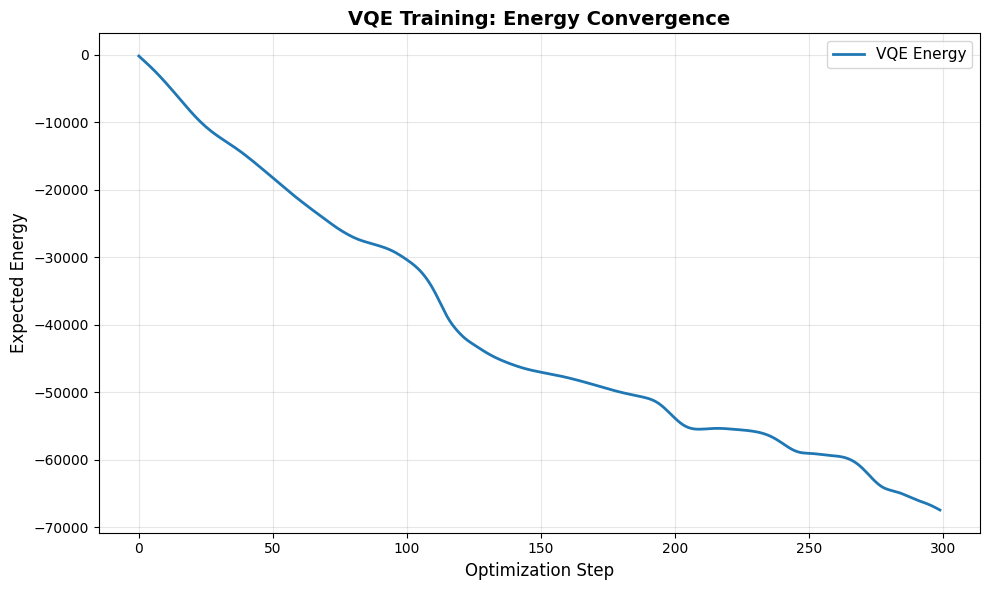

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(energy_hist, linewidth=2, label="VQE Energy")
plt.xlabel("Optimization Step", fontsize=12)
plt.ylabel("Expected Energy", fontsize=12)
plt.title("VQE Training: Energy Convergence", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Teste de sanidade por QUBO

In [14]:
def qubo_energy(Q, const, x):
    # x is a 0/1 vector length n_qubits
    E = const
    for (a, b), c in Q.items():
        E += c * x[a] * x[b]
    return float(E)


# xvec from your decoded bitstring:
xvec = bitstring.astype(int)
E_invalid = qubo_energy(Q, const_offset, xvec)


# build a valid tour matrix from a route, e.g. [0,1,2,3,4]
def route_to_xvec(route, n):
    x = np.zeros((n, n), dtype=int)
    for t, i in enumerate(route):
        x[i, t] = 1
    return x.reshape(-1)


valid_route = list(range(n))
E_valid = qubo_energy(Q, const_offset, route_to_xvec(valid_route, n))

print("E_invalid(QUBO) =", E_invalid)
print("E_valid(QUBO)   =", E_valid)

E_invalid(QUBO) = 163872.8231422872
E_valid(QUBO)   = 284.2604917688732


## 7) Ótimo por força bruta (validação)

Para $n$ pequeno, calculamos o ótimo exato enumerando todas as permutações (fixar a primeira cidade remove ciclos equivalentes).


In [15]:
def brute_force_tsp(D):
    n = D.shape[0]
    best = None
    best_dist = float("inf")
    cities = list(range(n))

    # Fix start city to 0 to avoid rotational duplicates
    for perm in itertools.permutations(cities[1:]):
        route = (0,) + perm
        d = route_distance(route, D)
        if d < best_dist:
            best_dist = d
            best = route
    return best, best_dist

opt_route, opt_dist = brute_force_tsp(D)
print("Optimal route (brute force):", opt_route)
print("Optimal distance:", opt_dist)

if valid:
    print("VQE distance gap:", dist - opt_dist)
else:
    print("VQE produced an invalid tour; try increasing penalty A or training steps/layers.")


Optimal route (brute force): (0, 3, 2, 1, 4)
Optimal distance: 227.34551867849092
VQE produced an invalid tour; try increasing penalty A or training steps/layers.
